In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import json
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

In [2]:

def load_embeddings(file_path):
    with open(file_path, "r") as f:
        data = json.load(f)

    # convert to numpy
    for k in data:
        data[k] = np.array(data[k])

    return data

topic_embeddings = load_embeddings("../data/embeddings/topic_embeddings.json")

ministry_embeddings = load_embeddings("../data/embeddings/ministry_embeddings2.json")

In [3]:
topics = list(topic_embeddings.keys())
ministries = list(ministry_embeddings.keys())

# -------------------------------
# STEP 1: Build similarity matrix
# -------------------------------
sim_matrix = {}

for t in topics:
    sim_matrix[t] = {}
    for m in ministries:
        score = cosine_similarity(
            [topic_embeddings[t]], 
            [ministry_embeddings[m]]
        )[0][0]
        sim_matrix[t][m] = score

In [4]:
sim_matrix_df = pd.DataFrame(sim_matrix)

In [5]:
sim_matrix_df

,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
Ministry_of_Power_MoP_,0.370260,0.149078,0.374001,0.306204,0.128519,0.395753,0.307689,0.087293,0.166134,0.310557,...,0.192292,0.215408,0.278362,0.187362,0.162757,0.111652,0.560489,0.254614,0.225750,0.054140
Ministry_of_Micro_Small_Medium_Enterprises_MoME_,0.462388,0.225291,0.483077,0.366480,0.191717,0.357645,0.353889,0.168706,0.110016,0.407885,...,0.206998,0.321759,0.352714,0.321793,0.249010,0.183950,0.303234,0.304690,0.529772,0.121409
Ministry_of_AYUSH_MoA_,0.160957,0.086899,0.491376,0.267210,0.178586,0.218194,0.164851,0.016145,0.073078,0.333017,...,0.122855,0.164734,0.194087,0.309066,0.117571,0.363981,0.130122,0.242784,0.210752,0.671887
Ministry_of_Textiles_MoT_,0.463012,0.232819,0.296971,0.197675,0.098960,0.280830,0.308834,0.244237,0.071298,0.259806,...,0.178455,0.194873,0.277349,0.259505,0.175155,0.211286,0.209933,0.220137,0.679470,0.157560
Ministry_of_Personnel_Public_Grievances_and_Pensions_MoPPGP_,0.295860,0.211037,0.527889,0.318603,0.332378,0.501907,0.300391,0.078123,0.205753,0.349606,...,0.289643,0.330366,0.401523,0.393696,0.306928,0.111242,0.230893,0.494351,0.224097,0.186767
Ministry_of_Law_and_Justice_MoLJ_,0.188187,0.201244,0.346593,0.299466,0.657387,0.429553,0.255209,-0.027368,0.110680,0.422543,...,0.176579,0.294564,0.491707,0.297294,0.200415,0.089898,0.181721,0.380137,0.161648,0.070454
Ministry_of_Social_Justice_and_Empowerment_MoSJE_,0.206666,0.166380,0.520006,0.374976,0.365496,0.375703,0.221552,0.074459,0.135264,0.494844,...,0.183264,0.273504,0.356628,0.394334,0.355636,0.215421,0.201386,0.362305,0.208096,0.253853
Ministry_of_Culture,0.160322,0.180989,0.344826,0.353827,0.235859,0.301779,0.119136,0.139204,0.154612,0.338102,...,0.137060,0.153420,0.301989,0.279432,0.064994,0.394141,0.054281,0.306052,0.201977,0.151018
Ministry_of_Heavy_Industries_MoHI_,0.613630,0.201297,0.392335,0.294124,0.158972,0.396030,0.315938,0.174349,0.095610,0.340773,...,0.362196,0.312030,0.309083,0.288477,0.186131,0.146587,0.409252,0.341718,0.381153,0.111219
Ministry_of_Statistics_and_Programme_Implementation_MoSPI_,0.385354,0.179400,0.442468,0.286568,0.172738,0.659586,0.385072,0.077629,0.197312,0.354559,...,0.185698,0.166989,0.286338,0.286549,0.217296,0.121639,0.361275,0.328920,0.304493,0.140767


In [6]:

# save the max score
max_sim_score = sim_matrix_df.max(axis=1)

# for each ministry (row), find the topic with highest similarity
sim_matrix_df["Most Similar Topic"] = sim_matrix_df.idxmax(axis=1)

In [7]:
# print topic {id}: and ministries mapped to it
topic_to_ministries = {}
for topic in topics:
    topic_to_ministries[topic] = sim_matrix_df[sim_matrix_df["Most Similar Topic"] == topic].index.tolist()
    
for t in topic_to_ministries:
    print(f"\nTopic {t}:")
    for m in topic_to_ministries[t]:
        score = sim_matrix_df.loc[m, t]
        print("   ", m, f"({score*100:.2f}%)")


Topic 0:
    Ministry_of_Heavy_Industries_MoHI_ (61.36%)
    Ministry_of_Steel_MoS_ (54.81%)

Topic 1:
    Ministry_of_Information_and_Broadcasting_MIB_ (63.34%)

Topic 2:
    Ministry_of_Personnel_Public_Grievances_and_Pensions_MoPPGP_ (52.79%)
    Ministry_of_Social_Justice_and_Empowerment_MoSJE_ (52.00%)
    Ministry_of_Tourism_MoT_ (36.50%)
    Ministry_of_Youth_Affairs_and_Sports_MoYAS_ (43.72%)
    Ministry_of_Health_and_Family_Welfare_MoHFW_ (55.29%)
    Ministry_of_Development_of_North_Eastern_Region_MDoNER_ (55.04%)
    Ministry_of_Finance_MoF_ (47.58%)

Topic 3:
    Ministry_of_Cooperation_MoC_ (62.32%)

Topic 4:
    Ministry_of_Law_and_Justice_MoLJ_ (65.74%)
    Ministry_of_Minority_Affairs_MoMA_ (48.44%)

Topic 5:
    Ministry_of_Statistics_and_Programme_Implementation_MoSPI_ (65.96%)
    Ministry_of_Planning_MoP_ (61.21%)
    Ministry_of_Parliamentary_Affairs_MPA_ (60.77%)

Topic 6:
    Ministry_of_Electronics_and_Information_Technology_MeitY_ (54.59%)
    Ministry_of_Com

In [8]:
# using max_sim_score, and sim_matrix_df["Most Similar Topic"], build a dataframe with columns: "Topic", "Most Similar Ministry", "Similarity Score"
topic_ministry_df = pd.DataFrame({
    "TopicID": sim_matrix_df["Most Similar Topic"],
    "Score": max_sim_score
})
topic_ministry_df      

,TopicID,Score
Ministry_of_Power_MoP_,21,0.560489
Ministry_of_Micro_Small_Medium_Enterprises_MoME_,23,0.529772
Ministry_of_AYUSH_MoA_,24,0.671887
Ministry_of_Textiles_MoT_,23,0.679470
Ministry_of_Personnel_Public_Grievances_and_Pensions_MoPPGP_,2,0.527889
Ministry_of_Law_and_Justice_MoLJ_,4,0.657387
Ministry_of_Social_Justice_and_Empowerment_MoSJE_,2,0.520006
Ministry_of_Culture,11,0.424060
Ministry_of_Heavy_Industries_MoHI_,0,0.613630
Ministry_of_Statistics_and_Programme_Implementation_MoSPI_,5,0.659586


In [9]:
# reset index to get ministry as a column
topic_ministry_df = topic_ministry_df.reset_index().rename(columns={"index": "Ministry"})
topic_ministry_df[['TopicID', 'Ministry', 'Score']].to_csv("../data/topic_modeling/topic_ministry_mapping2.csv", index=False)

In [10]:
# print if any ministry is mapped to multiple topics
ministry_count = {}
for ministry in ministries:
    ministry_count[ministry] = sim_matrix_df[sim_matrix_df["Most Similar Topic"] == ministry].shape[0]
    
for ministry, count in ministry_count.items():
    if count > 1:
        print(f"{ministry} is mapped to {count} topics")

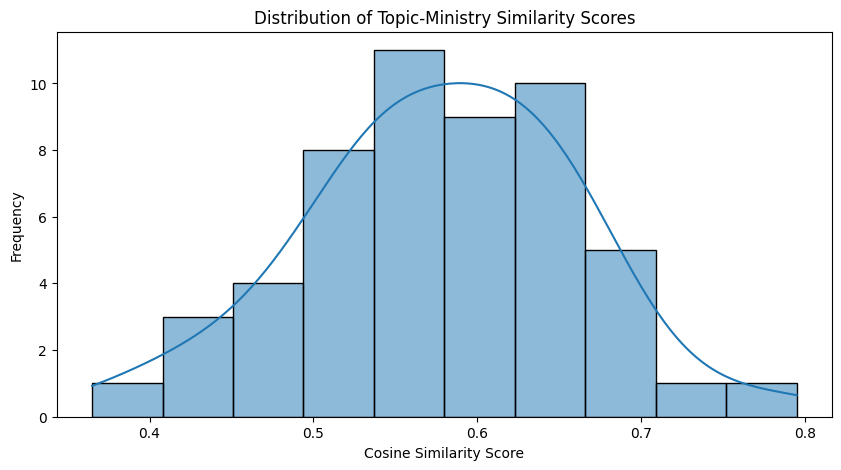

In [11]:
# plot score wise frequency distribution
plt.figure(figsize=(10,5))
sns.histplot(topic_ministry_df['Score'].values, bins=10, kde=True)
plt.title("Distribution of Topic-Ministry Similarity Scores")
plt.xlabel("Cosine Similarity Score")
plt.ylabel("Frequency")
plt.show()